In [171]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [172]:

class CardAlignment:
    def __init__(self, visualization=False):
        self.visualization_mode = visualization

    def crop_card(self, image):
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        _, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        max_contour = max(contours, key=cv2.contourArea)
        rect = cv2.minAreaRect(max_contour)
        box = cv2.boxPoints(rect)
        box = np.intp(box)
        card = image.copy()
        cv2.drawContours(card, [box], 0, (0, 255, 0), 2)
        (x, y, w, h) = cv2.boundingRect(box)
        card = card[y:y+h, x:x+w]
        return card, rect

    def align_card(self, card, rect_angle):
       height, width = card.shape[:2]
       if rect_angle < -45:
         rect_angle += 90
       elif rect_angle > 45:
         rect_angle -= 90
       rotation_matrix = cv2.getRotationMatrix2D((width / 2, height / 2), rect_angle, 1)
       aligned_card = cv2.warpAffine(card, rotation_matrix, (width, height), flags=cv2.INTER_LINEAR)
       return aligned_card


In [173]:
# Function to print the image
def plot_image(image):
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title('Output Image')
    plt.axis('off')
    plt.show()

In [174]:
def process_image(image):
    card_aligner = CardAlignment(visualization=True)
    card, rect = card_aligner.crop_card(image)
    rect_angle = rect[-1]
    aligned_card = card_aligner.align_card(card, rect_angle)

    # Check if additional cropping is required
    gray_aligned = cv2.cvtColor(aligned_card, cv2.COLOR_BGR2GRAY)
    _, thresh_aligned = cv2.threshold(gray_aligned, 1, 255, cv2.THRESH_BINARY)
    contours_aligned, _ = cv2.findContours(thresh_aligned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    max_contour_aligned = max(contours_aligned, key=cv2.contourArea)
    rect_aligned = cv2.minAreaRect(max_contour_aligned)
    box_aligned = cv2.boxPoints(rect_aligned)
    box_aligned = np.intp(box_aligned)

    # Calculate bounding box
    (x, y, w, h) = cv2.boundingRect(box_aligned)

    # Apply additional cropping if required
    if x > 0 or y > 0 or x + w < aligned_card.shape[1] or y + h < aligned_card.shape[0]:
        aligned_card = aligned_card[y:y+h, x:x+w]

    plot_image(aligned_card)
    return aligned_card

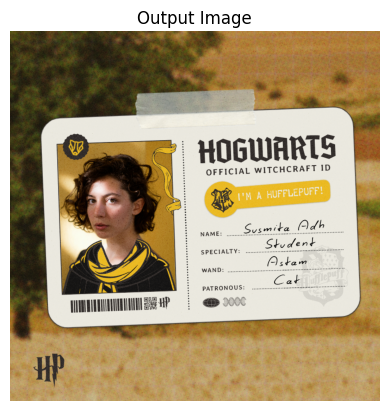

In [175]:
# Path to the image file
original_image = cv2.imread("../images/input/id4.png")
plot_image(original_image)

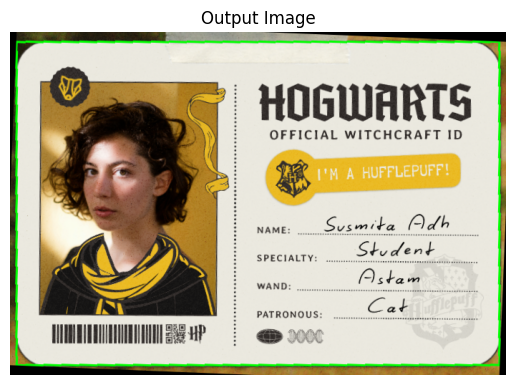

In [176]:
# Process the image
aligned_image = process_image(original_image)

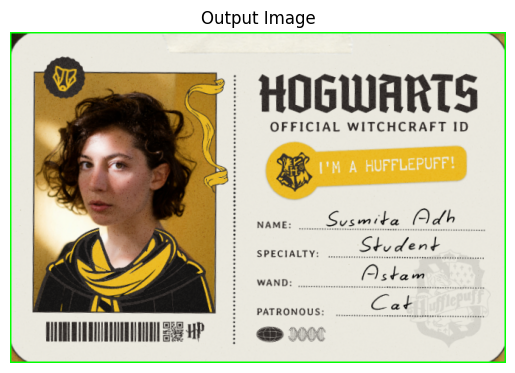

In [177]:
# Process the image
aligned_image1 = process_image(aligned_image)

In [178]:
import pytesseract


In [179]:
pytesseract.pytesseract.tesseract_cmd = r'C:\\Program Files\\Tesseract-OCR\\tesseract.exe'

In [180]:
import cv2
import numpy as np
import pytesseract
import matplotlib.pyplot as plt
import pandas as pd
import re
import datetime
import pytz

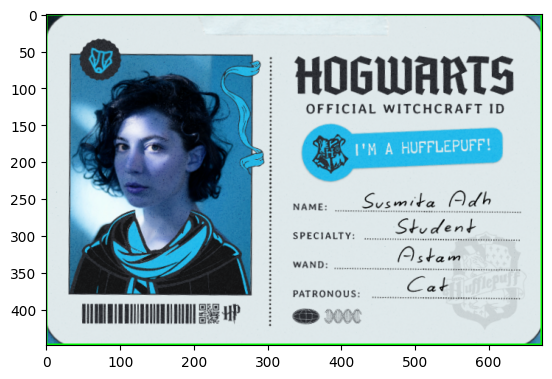

In [181]:
# Read the image
img = aligned_image1.copy()

# Make copies of the image
img_copy = img.copy()
specialty = img.copy()
name = img.copy()
wand = img.copy()
patronous = img.copy()
yellow = img.copy()
title = img.copy()

# Display the original image
plt.imshow(img)
plt.show()

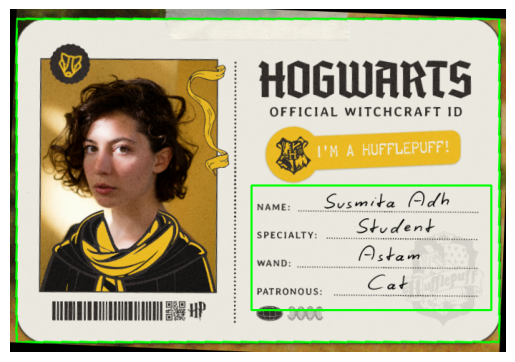

In [182]:
import cv2
import matplotlib.pyplot as plt

# Load the image
img_copy = aligned_image.copy()

# Get image dimensions
height, width, _ = img.shape

# Calculate the coordinates for the rectangle
top_left = (int(width * (2/4)), int(height * (2.2/4)))
bottom_right = (int(width * (8/8)), int(height * (3.75/4)))

# Define shrinkage percentages
shrink_percentage = 0.005

# Calculate the shrinkage amount
shrink_x = int((bottom_right[0] - top_left[0]) * shrink_percentage)
shrink_y = int((bottom_right[1] - top_left[1]) * shrink_percentage)

# Adjust the coordinates to shrink the rectangle
top_left = (top_left[0] + shrink_x, top_left[1] + shrink_y)
bottom_right = (bottom_right[0] - shrink_x, bottom_right[1] - shrink_y)

# Draw the rectangle on the image
green_color = (0, 255, 0)  # Green color in BGR
border_thickness = 2  # Thickness of the border
cv2.rectangle(img_copy, top_left, bottom_right, green_color, border_thickness)

# Convert BGR image to RGB for displaying with matplotlib
img_rgb = cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB)

# Display the image with the rectangle
plt.imshow(img_rgb)
plt.axis('off')  # Turn off axis
plt.show()


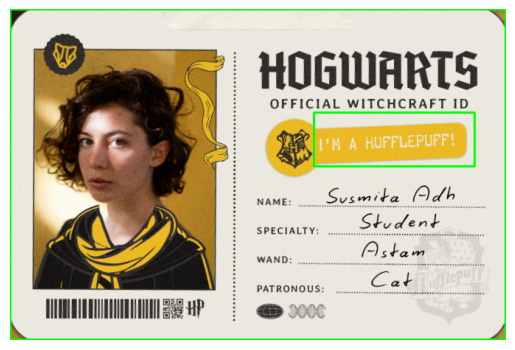

In [183]:
# Define the coordinates for the line rectangle
top_left_yellow = (int(width * (2.45/4) ), int(height * (1.9/4)) )
bottom_right_yellow = (int(width * (7.5/8)), int(height * (1.25/4)))

cv2.rectangle(yellow, top_left_yellow, bottom_right_yellow, green_color, border_thickness)

# Convert BGR image to RGB for displaying with matplotlib
img_rgb_1 = cv2.cvtColor(yellow, cv2.COLOR_BGR2RGB)

# Display the image with the rectangles
plt.imshow(img_rgb_1)
plt.axis('off')  # Turn off axis
plt.show()

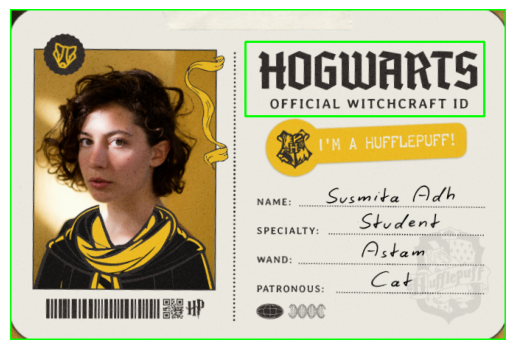

In [184]:
# Define the coordinates for the line rectangle
top_left_title = (int(width * (1.9/4) ), int(height * (1.3/4)) )
bottom_right_title = (int(width * (7.65/8)), int(height * (0.4/4)))

cv2.rectangle(title, top_left_title, bottom_right_title, green_color, border_thickness)

# Convert BGR image to RGB for displaying with matplotlib
img_rgb_1 = cv2.cvtColor(title, cv2.COLOR_BGR2RGB)

# Display the image with the rectangles
plt.imshow(img_rgb_1)
plt.axis('off')  # Turn off axis
plt.show()

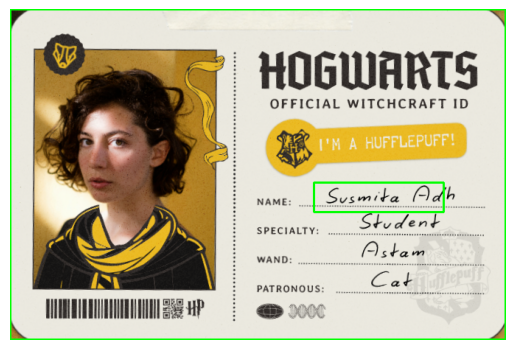

In [185]:
# Define the coordinates for the line rectangle
top_left_name = (int(width * (2.45/4) ), int(height * (2.45/4)) )
bottom_right_name = (int(width * (7/8)), int(height * (2.1/4)))

cv2.rectangle(name, top_left_name, bottom_right_name, green_color, border_thickness)

# Convert BGR image to RGB for displaying with matplotlib
img_rgb_1 = cv2.cvtColor(name, cv2.COLOR_BGR2RGB)

# Display the image with the rectangles
plt.imshow(img_rgb_1)
plt.axis('off')  # Turn off axis
plt.show()

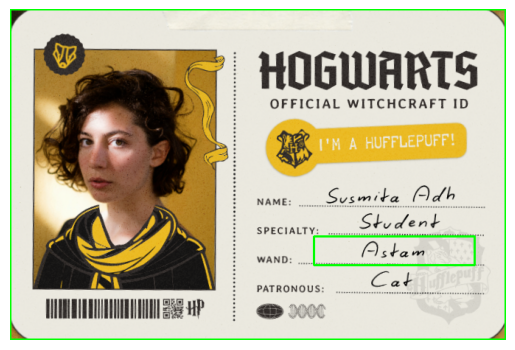

In [186]:
# Define the coordinates for the line rectangle
top_left_wand = (int(width * (2.45/4) ), int(height * (2.75/4)) )
bottom_right_wand = (int(width * (7.5/8)), int(height * (3.10/4)))

cv2.rectangle(wand, top_left_wand, bottom_right_wand, green_color, border_thickness)

# Convert BGR image to RGB for displaying with matplotlib
img_rgb_1 = cv2.cvtColor(wand, cv2.COLOR_BGR2RGB)

# Display the image with the rectangles
plt.imshow(img_rgb_1)
plt.axis('off')  # Turn off axis
plt.show()

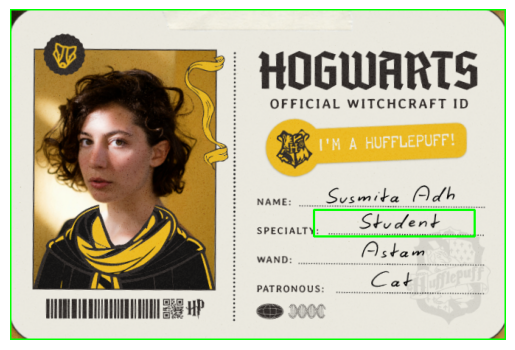

In [187]:
# Define the coordinates for the line rectangle
top_left_1_spec = (int(width * (2.45/4) ), int(height * (2.75/4)) )
bottom_right_1_spec = (int(width * (7.5/8)), int(height * (2.43/4)))

cv2.rectangle(specialty, top_left_1_spec, bottom_right_1_spec, green_color, border_thickness)

# Convert BGR image to RGB for displaying with matplotlib
img_rgb_1 = cv2.cvtColor(specialty, cv2.COLOR_BGR2RGB)

# Display the image with the rectangles
plt.imshow(img_rgb_1)
plt.axis('off')  # Turn off axis
plt.show()

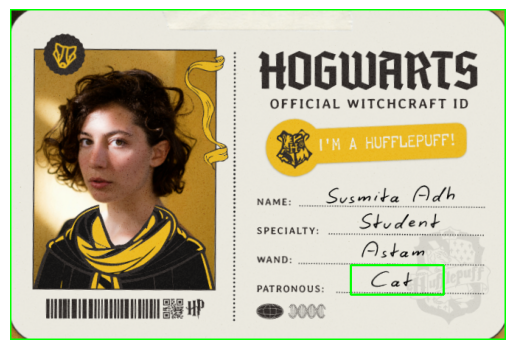

In [188]:
# Define the coordinates for the line rectangle
top_left_1 = (int(width * (2.75/4) ), int(height * (3.45/4)) )
bottom_right_1 = (int(width * (7/8)), int(height * (3.10/4)))

cv2.rectangle(patronous, top_left_1, bottom_right_1, green_color, border_thickness)

# Convert BGR image to RGB for displaying with matplotlib
img_rgb_1 = cv2.cvtColor(patronous, cv2.COLOR_BGR2RGB)

# Display the image with the rectangles
plt.imshow(img_rgb_1)
plt.axis('off')  # Turn off axis
plt.show()

In [189]:
# import cv2
# import numpy as np
# import matplotlib.pyplot as plt

# # Assuming img_copy is defined with dimensions (height, width, channels)
# height, width, channels = img_copy.shape

# # Create a mask to cover the entire image
# mask_0 = np.zeros((height, width), dtype=np.uint8)

# # Draw the filled rectangle on the mask
# cv2.rectangle(mask_0, top_left, bottom_right, (255), -1)

# # Invert the mask
# mask_0 = cv2.bitwise_not(mask_0)

# # Create a white image of the same size and type as img_copy
# white_image = np.ones_like(img_copy, dtype=img_copy.dtype) * 255

# # Combine the original image and the white image using the mask
# result = cv2.bitwise_or(img_copy, white_image, mask=mask_0)

# # Display the result
# plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
# plt.axis('off')
# plt.show()


In [190]:
# # Iterate over each pixel in the result image
# for y in range(result.shape[0]):
#     for x in range(result.shape[1]):
#         # If the pixel in the result image is white
#         if np.all(result[y, x] == [255, 255, 255]):
#             # Set the corresponding pixel in the copy image to white
#             img_copy[y, x] = [255, 255, 255]

# # Display the result
# plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
# plt.axis('off')
# plt.show()

In [191]:
# import cv2
# import numpy as np
# import matplotlib.pyplot as plt

# # Assuming img_copy is defined with dimensions (height, width, channels)
# height, width, channels = name.shape

# # Create a mask to cover the entire image
# mask1 = np.zeros((height, width), dtype=np.uint8)

# # Draw the filled rectangle on the mask
# cv2.rectangle(mask1, top_left_name, bottom_right_name, (255), -1)

# # Invert the mask
# mask1 = cv2.bitwise_not(mask1)

# # Create a white image of the same size and type as img_copy
# white_image = np.ones_like(name, dtype=img_copy.dtype) * 255

# # Combine the original image and the white image using the mask
# result_1 = cv2.bitwise_or(name, white_image, mask=mask1)

# # Display the result_1
# plt.imshow(cv2.cvtColor(result_1, cv2.COLOR_BGR2RGB))
# plt.axis('off')
# plt.show()


In [192]:
# # Iterate over each pixel in the result_1 image
# for y in range(result_1.shape[0]):
#     for x in range(result_1.shape[1]):
#         # If the pixel in the result_1 image is white
#         if np.all(result_1[y, x] == [255, 255, 255]):
#             # Set the corresponding pixel in the copy image to white
#             name[y, x] = [255, 255, 255]

# # Display the result_1
# plt.imshow(cv2.cvtColor(name, cv2.COLOR_BGR2RGB))
# plt.axis('off')
# plt.show()

In [193]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_rectangle_mask(image, top_left, bottom_right):
    """
    Applies a rectangular mask to an image and sets the masked area to white.
    
    Parameters:
        image (numpy.ndarray): Input image.
        top_left (tuple): Coordinates of the top-left corner of the rectangle (x, y).
        bottom_right (tuple): Coordinates of the bottom-right corner of the rectangle (x, y).
    
    Returns:
        numpy.ndarray: Modified image with the masked area set to white.
    """
    # Validate input image
    if len(image.shape) != 3:
        raise ValueError("The input image must be a color image with 3 channels (BGR).")
    
    # Get dimensions of the image
    height, width, channels = image.shape

    # Create a mask to cover the entire image
    mask = np.zeros((height, width), dtype=np.uint8)

    # Draw the filled rectangle on the mask
    cv2.rectangle(mask, top_left, bottom_right, 255, -1)

    # Invert the mask
    mask = cv2.bitwise_not(mask)

    # Create a white image of the same size and type as the input image
    white_image = np.ones_like(image, dtype=image.dtype) * 255

    # Combine the original image and the white image using the mask
    result = image.copy()
    for channel in range(channels):
        result[:, :, channel] = cv2.bitwise_or(image[:, :, channel], white_image[:, :, channel], mask=mask)

    # Iterate over each pixel in the result image to set the white pixels in the original image
    for y in range(result.shape[0]):
        for x in range(result.shape[1]):
            # If the pixel in the result image is white
            if np.all(result[y, x] == [255, 255, 255]):
                # Set the corresponding pixel in the input image to white
                image[y, x] = [255, 255, 255]

    return image


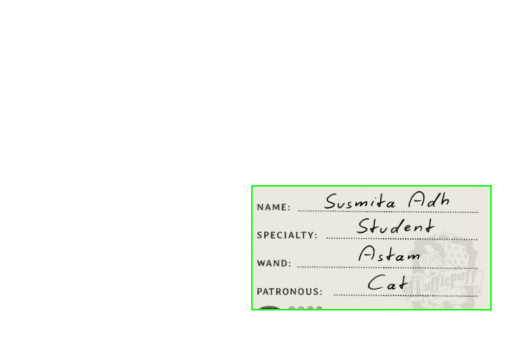

In [194]:

# Apply the function
modified_image = apply_rectangle_mask(img_copy, top_left = top_left, bottom_right=bottom_right)

# Display the result
plt.imshow(cv2.cvtColor(modified_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


In [195]:
name_image = apply_rectangle_mask(name, top_left_name, bottom_right_name)
wand_image = apply_rectangle_mask(wand, top_left_wand, bottom_right_wand)
patronous_image = apply_rectangle_mask(patronous, top_left_1, bottom_right_1)
specialty_image = apply_rectangle_mask(specialty, top_left_1_spec, bottom_right_1_spec)

In [196]:
yellow_image = apply_rectangle_mask(yellow, top_left_yellow, bottom_right_yellow)
title_image = apply_rectangle_mask(title, top_left_title, bottom_right_title)

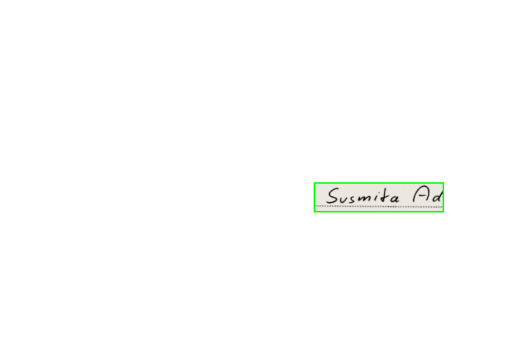

In [197]:
plt.imshow(cv2.cvtColor(name_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

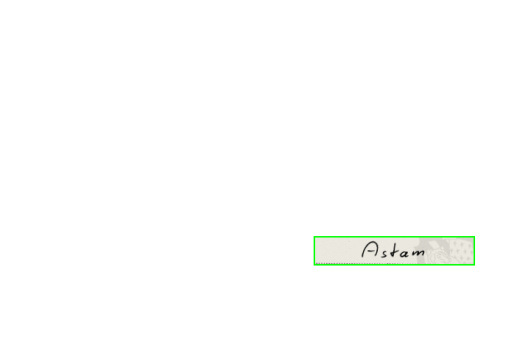

In [198]:
plt.imshow(cv2.cvtColor(wand_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

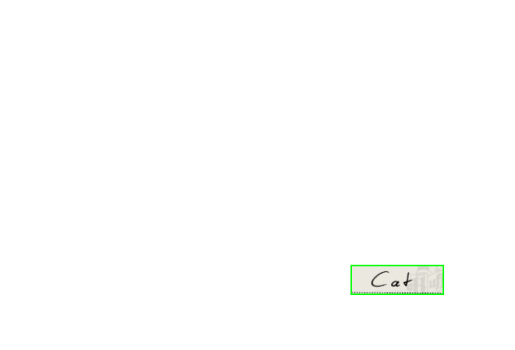

In [199]:
plt.imshow(cv2.cvtColor(patronous_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

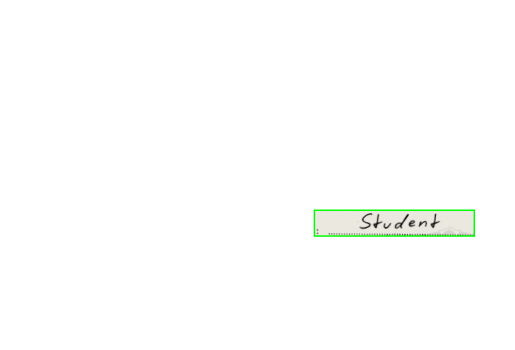

In [200]:
plt.show()
plt.imshow(cv2.cvtColor(specialty_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

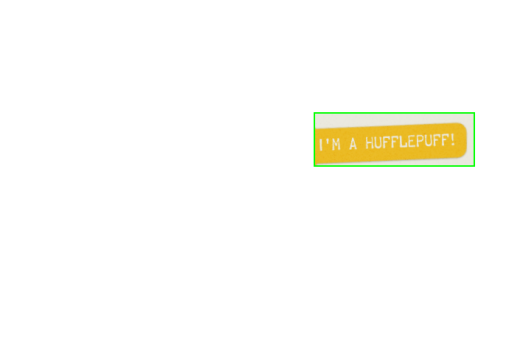

In [201]:
plt.imshow(cv2.cvtColor(yellow_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

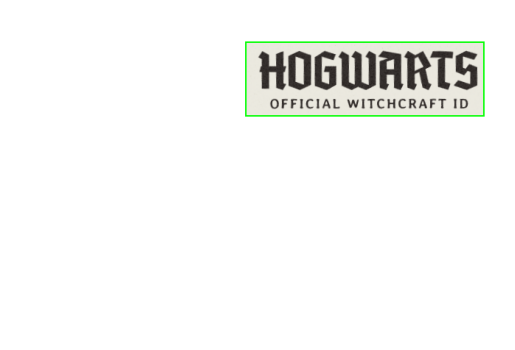

In [202]:
plt.imshow(cv2.cvtColor(title_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# Hurray Let's extract the text using keras it's too easy
### Lets build piple and start generating it 

import keras_ocr

In [209]:
import keras_ocr



In [210]:
pipeline = keras_ocr.pipeline.Pipeline()


Looking for C:\Users\Admin\.keras-ocr\craft_mlt_25k.h5
Looking for C:\Users\Admin\.keras-ocr\crnn_kurapan.h5


In [211]:
def extract_text(img):
    image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    predictions = pipeline.recognize([image_rgb])  # Returns a list of lists (per image)
    
    # Extract text from the first (and only) image's predictions
    text = [text for text,_ in predictions[0]]
    full_text = " ".join(text)
    return full_text

In [212]:
type(name_image)

numpy.ndarray

In [213]:
image_variables = [name_image, wand_image, patronous_image, specialty_image, yellow_image, title_image]
labels = ["name", "wand", "patronous", "specialty", "yellow", "title"]



In [214]:
import json

In [215]:
# Your images and corresponding labels
image_variables = [name_image, wand_image, patronous_image, specialty_image, yellow_image, title_image]
labels = ["name", "wand", "patronous", "specialty", "yellow", "title"]

# Create a dictionary with extracted text
result_dict = {}
for label, img in zip(labels, image_variables):
    result_dict[label] = extract_text(img)

# Convert to JSON
json_output = json.dumps(result_dict, indent=4)
print(json_output)

# Optionally save to file
with open('harry_potter_data.json', 'w') as f:
    json.dump(result_dict, f, indent=4)

1/1 [==============================] - 0s 45ms/step
{
    "name": "ad sssmita",
    "wand": "astam",
    "patronous": "cat",
    "specialty": "sident",
    "yellow": "hufflepuffl a im",
    "title": "hogwarts witchcraft official id"
}
